# Greek Dinner Sales
This notebook tests your skills on creating logical (flag) variables and using them to create custom insights. Similar to what you would use 'sumifs' in Excel.

**Dr. Dave Wanik - Unviversity of Connecticut - Dept. Operations and Information Management**

In [ ]:
import pandas as pd
import numpy as np

# Read the Data

I recommend all students open up the raw file in Excel first to explore what's going on with this dirty dataset.

💡If you prepare your data as separate clean files (!) this will make all of this way easier.

In [ ]:
# https://docs.google.com/spreadsheets/d/1f1OBTCqEcZiCDuUQhMEiSLxATEW1dIbh/edit?usp=sharing&ouid=118154520763102479420&rtpof=true&sd=true
!gdown 1f1OBTCqEcZiCDuUQhMEiSLxATEW1dIbh

Downloading...
From: https://drive.google.com/uc?id=1f1OBTCqEcZiCDuUQhMEiSLxATEW1dIbh
To: /content/Greek Restaurant Dinner - Data(1).xlsx
100% 23.8k/23.8k [00:00<00:00, 98.7MB/s]


In [ ]:
df = pd.read_excel('/content/Greek Restaurant Dinner - Data(1).xlsx')

**YUCK.** Look at all of this junk. When you try to open an Excel file that has custom formatting scattered throughout, pandas has no idea what to do... so it reads everything.

In [ ]:
df.head()

,Date,Weekday,Lunch,Dinner,Quarter,Senior Day,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Quarter.1,Senior Day.1
0,2020-01-01 00:00:00,NaN,743,3148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quarter 1,Yes
1,2020-01-02 00:00:00,NaN,843,1248,NaN,NaN,NaN,NaN,Total Dinner Sales of Quarter 1 + Senior Day,NaN,NaN,NaN,NaN,Quarter 2,No
2,2020-01-03 00:00:00,NaN,1403,3019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quarter 3,NaN
3,2020-01-04 00:00:00,NaN,1397,1887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Quarter 4,NaN
4,2020-01-05 00:00:00,NaN,861,1200,NaN,Yes,NaN,NaN,Total Dinner Sales of Quarter 4 + Sunday,NaN,NaN,NaN,NaN,NaN,NaN


## Restaurant Data

We just need the first six columns. Remember that Python counts from zero.

In [ ]:
df = df.iloc[:,:6] # up to but no including column 6
df.head()

,Date,Weekday,Lunch,Dinner,Quarter,Senior Day
0,2020-01-01 00:00:00,NaN,743,3148,NaN,NaN
1,2020-01-02 00:00:00,NaN,843,1248,NaN,NaN
2,2020-01-03 00:00:00,NaN,1403,3019,NaN,NaN
3,2020-01-04 00:00:00,NaN,1397,1887,NaN,NaN
4,2020-01-05 00:00:00,NaN,861,1200,NaN,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        366 non-null    object 
 1   Weekday     0 non-null      float64
 2   Lunch       366 non-null    int64  
 3   Dinner      366 non-null    int64  
 4   Quarter     0 non-null      float64
 5   Senior Day  62 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 17.3+ KB


We notice that the `Weekday` and `Quarter` columns are empty - let's fill them in! You can either use a lookup table (found in other parts of the Excel worksheet) or you can just use basic functionality in Python to clean this up for you.

## Using basic Python functionality to impute `Weekday` and `Quarter`

In order to leverage the full datetime functionalities of pandas... your data must be in `datetime` format! Which column has the date information in it? The `Date` column.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info() # check the data type
df.head() # note how the format has changed

DateParseError: ignored

**UH OH!** Pandas doesn't know how to deal with an erroneous date. Scroll down to row 89 (ish) and you will find `3/38/2020`. Clearly it should probably be `3/30/2020`.

Sometimes if the dataset is small enough (less than 1000 rows), you can manually spot these errors and correct them and start again. Sometimes if your dataset has 1M rows, you will never be able to manually check each little thing. Let's use a replace statement to clean this one example up and then try the code again.

In [ ]:
df['Date'].replace("3/38/2020", "3/30/2020", inplace=True)

### Second attempt

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info() # check the data type
df.head(92) # note how the format has changed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        366 non-null    datetime64[ns]
 1   Weekday     0 non-null      float64       
 2   Lunch       366 non-null    int64         
 3   Dinner      366 non-null    int64         
 4   Quarter     0 non-null      float64       
 5   Senior Day  62 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 17.3+ KB


,Date,Weekday,Lunch,Dinner,Quarter,Senior Day
0,2020-01-01,NaN,743,3148,NaN,NaN
1,2020-01-02,NaN,843,1248,NaN,NaN
2,2020-01-03,NaN,1403,3019,NaN,NaN
3,2020-01-04,NaN,1397,1887,NaN,NaN
4,2020-01-05,NaN,861,1200,NaN,Yes
...,...,...,...,...,...,...
87,2020-03-28,NaN,1279,2401,NaN,NaN
88,2020-03-29,NaN,1124,2248,NaN,Yes
89,2020-03-30,NaN,3308,12467,NaN,NaN
90,2020-03-31,NaN,4475,16848,NaN,NaN


Much better! One of the best parts about DateTime data types is that your X axis looks so much nicer once you make dates a datetime.

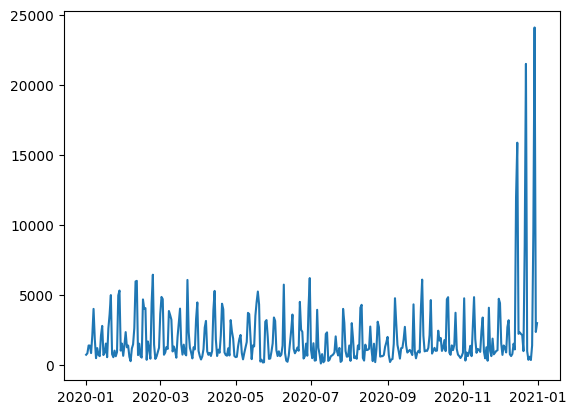

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['Date'], df['Lunch'])
plt.show()

As an exercise, you should add labels anad titles and a legend. Google it if you need help!

### Weekday
0 is Sunday, 1 is Monday... 6 is Saturday...

* https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.weekday.html

In [ ]:
df['Weekday'] = df['Date'].dt.dayofweek
df.head(n=10)

,Date,Weekday,Lunch,Dinner,Quarter,Senior Day
0,2020-01-01,2,743,3148,NaN,NaN
1,2020-01-02,3,843,1248,NaN,NaN
2,2020-01-03,4,1403,3019,NaN,NaN
3,2020-01-04,5,1397,1887,NaN,NaN
4,2020-01-05,6,861,1200,NaN,Yes
5,2020-01-06,0,2130,4568,NaN,NaN
6,2020-01-07,1,4015,4600,NaN,NaN
7,2020-01-08,2,1867,4018,NaN,NaN
8,2020-01-09,3,499,1000,NaN,NaN
9,2020-01-10,4,1215,2500,NaN,NaN


### Quarter
There are many ways to get this... but if you don't have custom date ranges, use pandas!

* https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.quarter.html

In [ ]:
df['Quarter'] = df['Date'].dt.quarter
df.head(n=95)

,Date,Weekday,Lunch,Dinner,Quarter,Senior Day
0,2020-01-01,2,743,3148,1,NaN
1,2020-01-02,3,843,1248,1,NaN
2,2020-01-03,4,1403,3019,1,NaN
3,2020-01-04,5,1397,1887,1,NaN
4,2020-01-05,6,861,1200,1,Yes
...,...,...,...,...,...,...
90,2020-03-31,1,4475,16848,1,NaN
91,2020-04-01,2,1012,2015,2,NaN
92,2020-04-02,3,648,1348,2,NaN
93,2020-04-03,4,404,897,2,NaN


Of course you can use value_counts() if you want to check your work even more.

## [optional] Joining data together with a lookup table (similar to Excel)
This will be covered in an Excel-only video next week.

The current form of the worksheet is a bit dirty - you will need to make your own tables to extract the data on the "Lookup Tables" tab.

Believe it or not, you will need to read in the entire Excel sheet again and specify that you want the "Lookup Tables" tab. Like this...

In [ ]:
theLookup = pd.read_excel('/content/Greek Restaurant Dinner - Data(1).xlsx', sheet_name="Lookup Tables")

theLookup.head(n=15) # of course, it's clunky.

,Number,Day
0,1,Sunday
1,2,Monday
2,3,Tuesday
3,4,Wednesday
4,5,Thursday
5,6,Friday
6,7,Saturday
7,NaN,NaN
8,Breakpoints,Quarter
9,1,Quarter 1


What would I do in the real-world? Probably copy/paste the data into another sheet. But since this is an academic class, you could go ahead and extract these two tables with Python, clean them up, then join again. I leave this to you as an exercise, let me know if you need help with joins in Python! We will have more examples later on.

In [ ]:
dayLookup = theLookup[0:7]
dayLookup

,Number,Day
0,1,Sunday
1,2,Monday
2,3,Tuesday
3,4,Wednesday
4,5,Thursday
5,6,Friday
6,7,Saturday


In [ ]:
# this is so messy, it might be easier to skip rows and read the file again
quarterLookup = theLookup[8:]
quarterLookup

,Number,Day
8,Breakpoints,Quarter
9,1,Quarter 1
10,4,Quarter 2
11,7,Quarter 3
12,10,Quarter 4


In [ ]:
quarterLookup = pd.read_excel('/content/Greek Restaurant Dinner - Data(1).xlsx', sheet_name="Lookup Tables", skiprows=9)

quarterLookup.head()

,Breakpoints,Quarter
0,1,Quarter 1
1,4,Quarter 2
2,7,Quarter 3
3,10,Quarter 4


You could then do a join - but be careful! You will likely get a data types issue (integer vs. object... you will need to convert one so data types are the same - **you can't do a join on two different data types**.) Feel try to try on your own or ask during office hours. Note that Excel and Python treat days of the week differently!
* 1 (Sunday) to 7 (Saturday) for Excel
* 0 (Sunday) to 6 (Saturday) for Python

# 🔴 Question 1: Total Dinner Sales of Quarter 1 `AND` Senior Day.

# 🔴 Question 2: Total Dinner Sales of Quarter 4 `AND` Sunday.

# 🔴 Question 3: Count of Senior Day.

# 🔴 Question 4: Count of Senior Day `AND` Quarter 1.

# 🔴 Question 5: Average Dinner Sales of Senior Day `AND` Quarter 1.